In [11]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.datasets import fashion_mnist
import cv2

In [13]:
(x_train,y_train) , (x_test,y_test) = fashion_mnist.load_data()

In [14]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [15]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [16]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

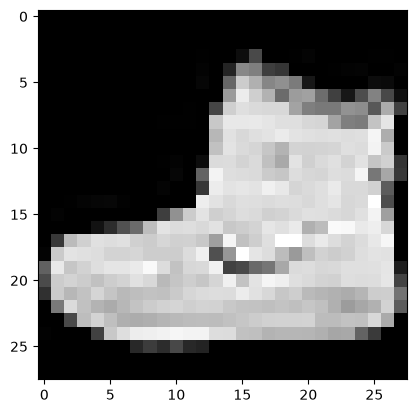

In [17]:
plt.imshow(x_train[0],cmap="gray")
plt.show()

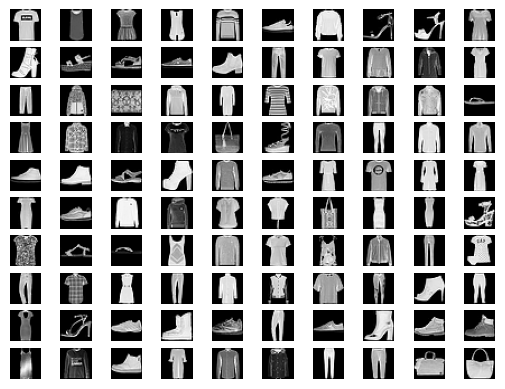

In [18]:
for i in range(1,101):
  plt.subplot(10,10,i)
  plt.imshow(x_train[i],cmap="gray")
  plt.axis("off")

# CNN = Concolutional Neural Network

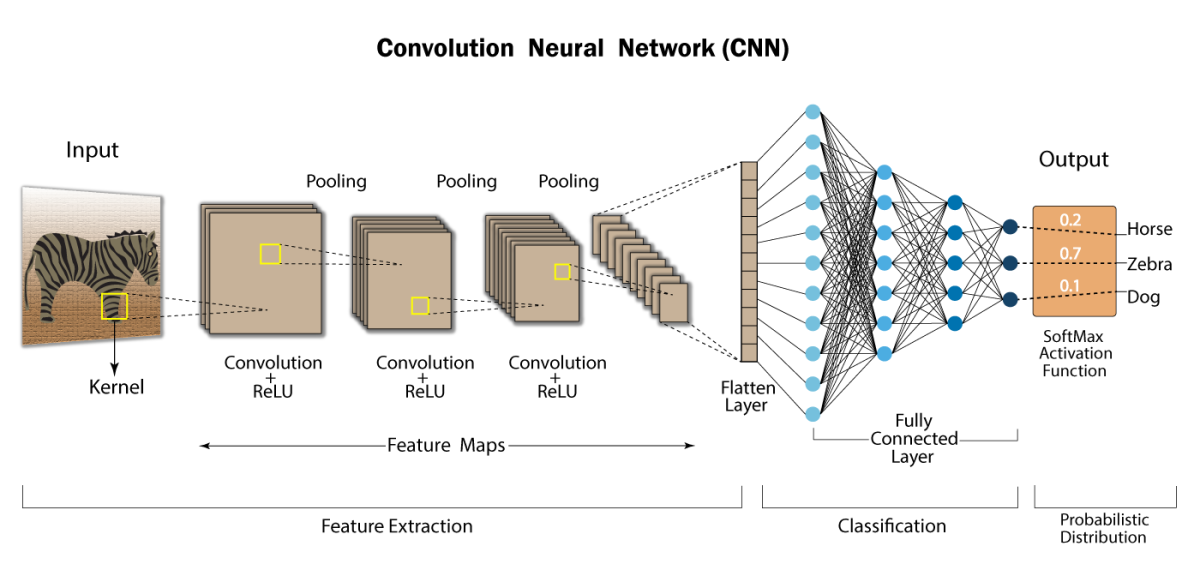

# Convolution Layer

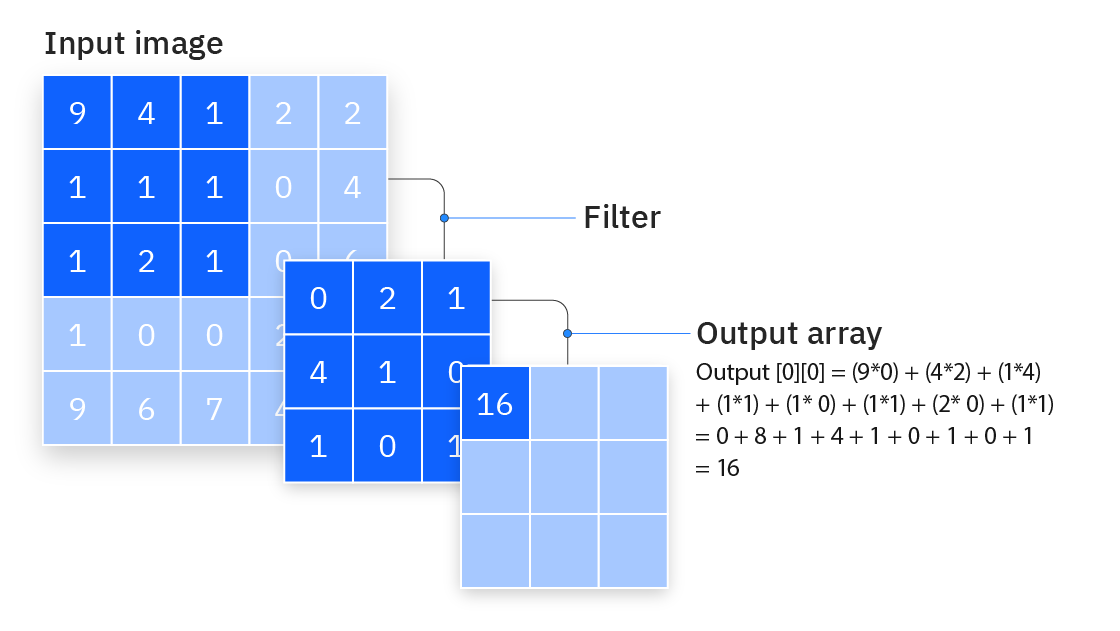

# Different Filters

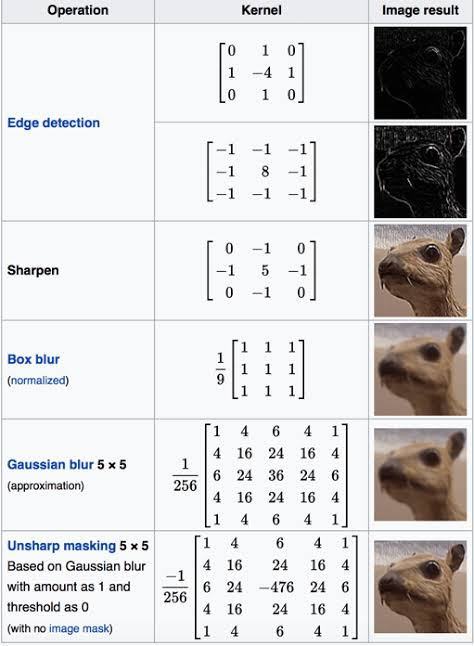

In [19]:
# 9*0 + 4*2 + 1*1 + 1*4 + 1*1 + 1*0 + 1*1 + 2*0 + 1*1
# = 0 + 8 + 1 + 4 + 1 + 0 + 1 + 0 + 1
# = 16

# Pooling Layer

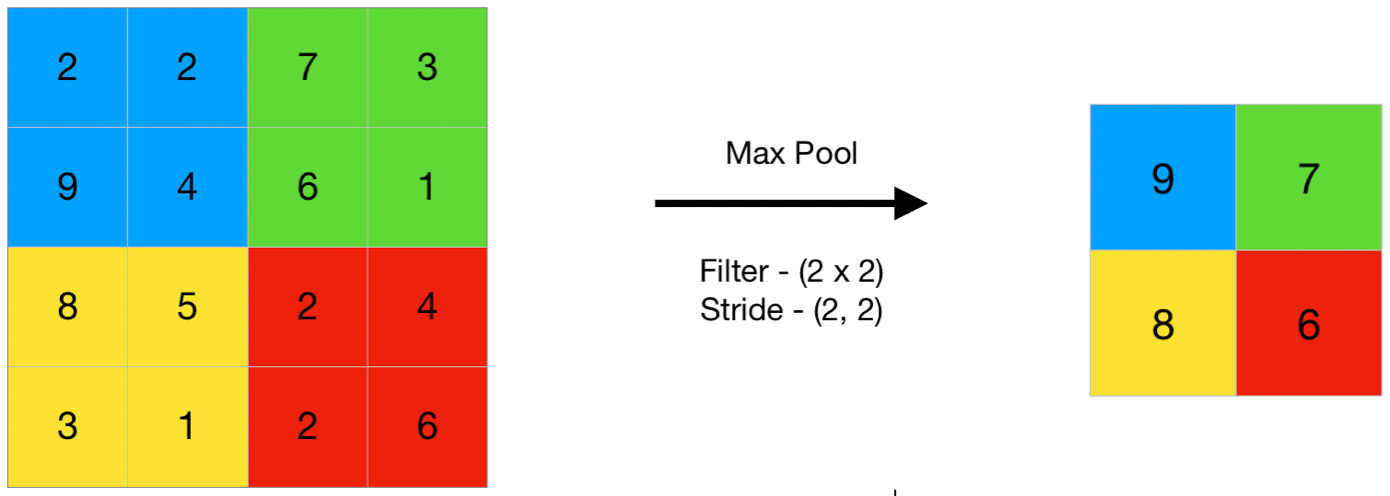

# Flatten Layer

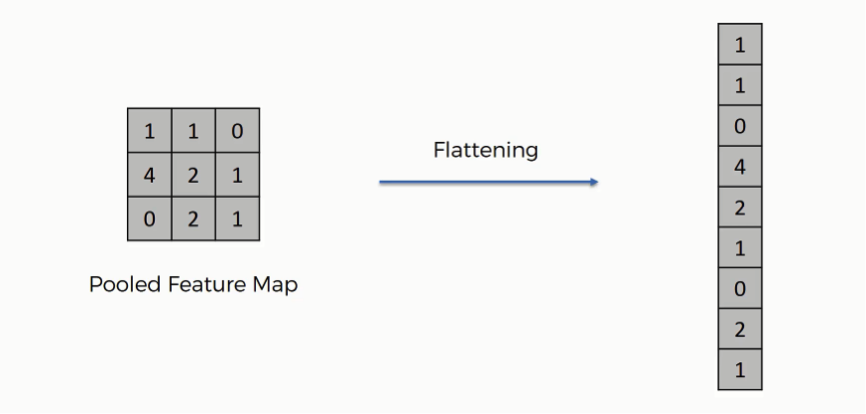

In [20]:
x_train[0].shape

(28, 28)

# Activation Function تابع فعال سازی

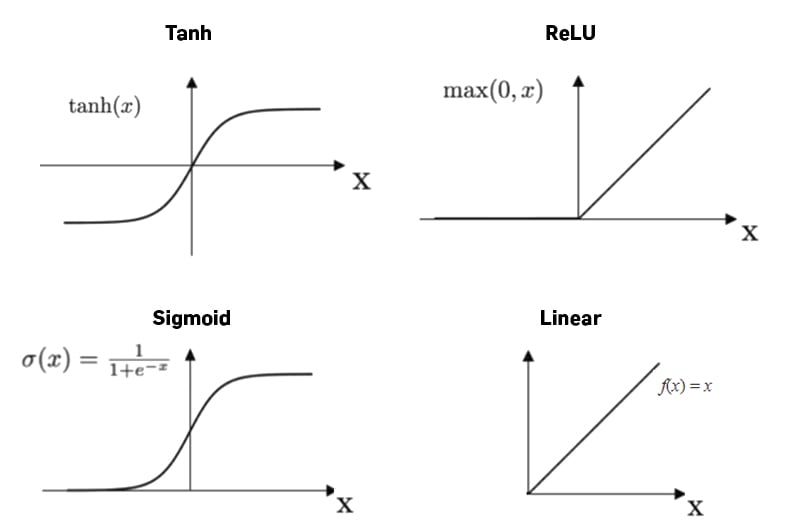

In [21]:
model = Sequential()

model.add(Conv2D(filters=256,kernel_size=(3,3),activation="relu",input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2),strides=(2,2)))

model.add(Conv2D(filters=128,kernel_size=(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2),strides=(2,2)))

model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2),strides=(2,2)))

model.add(Flatten())

model.add(Dense(units=128 , activation="relu"))
model.add(Dense(units=10, activation="softmax"))

c:\Users\pouya\AppData\Local\Programs\Python\Python314\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics = ["accuracy"])

In [23]:
hist = model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.8056 - loss: 0.5964 - val_accuracy: 0.8397 - val_loss: 0.4405
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.8532 - loss: 0.4075 - val_accuracy: 0.8513 - val_loss: 0.4108
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.8674 - loss: 0.3634 - val_accuracy: 0.8665 - val_loss: 0.3833
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.8773 - loss: 0.3339 - val_accuracy: 0.8657 - val_loss: 0.3837
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 41ms/step - accuracy: 0.8867 - loss: 0.3062 - val_accuracy: 0.8700 - val_loss: 0.3690
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.8942 - loss: 0.2868 - val_accuracy: 0.8711 - val_loss: 0.3793
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 77s 41ms/step - accuracy: 0.8975 - loss: 0.2718 - val_accuracy: 0.8756 - val_loss: 0.3768
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.9037 -

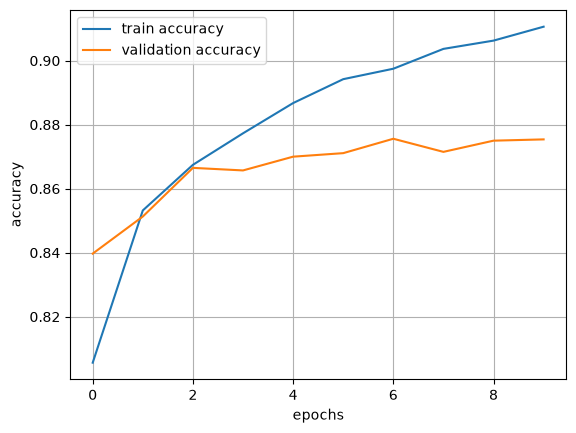

In [24]:
plt.plot(hist.history["accuracy"],label="train accuracy")
plt.plot(hist.history["val_accuracy"],label="validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.grid()
plt.show()

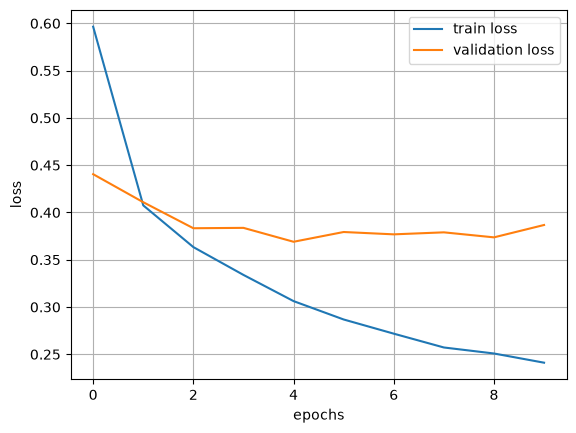

In [25]:
plt.plot(hist.history["loss"],label="train loss")
plt.plot(hist.history["val_loss"],label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.grid()
plt.show()

In [26]:
image = cv2.imread("/content/content.png")
print(image.shape)

image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
image_gray = cv2.resize(image_gray,(28,28))
print(image.shape)

plt.subplot(1,2,1)
plt.imshow(image)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image_gray,cmap="gray")
plt.axis("off")
plt.show()

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
classes = ["T-shirt/top", "Trouser" , "Pullover" ,
           "Dress", "Coat", "Sandal", "Shirt", "Sneaker",
           "Bag", "Ankle boot"]

In [ ]:
image_gray = image_gray.reshape(1,28,28,1)
y_pred = model.predict(image_gray)
y_result = np.argmax(y_pred)
y_class = classes[y_result]
print("it is a",y_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
it is a Bag
